In [1]:
import os
import cv2
import numpy as np
from imutils import paths
from sklearn.model_selection import StratifiedGroupKFold
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy
import math

# -------------------------------------------------
# Device Configuration
# -------------------------------------------------
print(f"Number of GPUs available: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}\n')

# -------------------------------------------------
# Hyperparameters (stronger regularization for hard folds)
# -------------------------------------------------
batch_size = 32
num_epochs = 30
learning_rate = 2e-4
weight_decay = 5e-4
img_rows, img_cols = 128, 128
n_folds = 5
early_stop_patience = 7
min_epochs = 6
dropout_p = 0.55
spatial_dropout_p = 0.30

# -------------------------------------------------
# Paths
# -------------------------------------------------
control_folder = r'C:\Users\RTX2080Ti\Desktop\Dyslexia DL\FCM\control'
dyslexia_folder = r'C:\Users\RTX2080Ti\Desktop\Dyslexia DL\FCM\dyslexia'

# -------------------------------------------------
# Load data (group-aware)
# -------------------------------------------------
def load_images_from_folder(folder, label):
    data = []
    for imagePath in paths.list_images(folder):
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (img_cols, img_rows))
        filename = os.path.basename(imagePath)
        group_id = filename.split('_')[0]
        data.append((image, label, group_id))
    return data

control_data = load_images_from_folder(control_folder, 0)
dyslexia_data = load_images_from_folder(dyslexia_folder, 1)
data = control_data + dyslexia_data
np.random.seed(42)
np.random.shuffle(data)

X = np.array([d[0] for d in data], dtype=np.float32)
y = np.array([d[1] for d in data], dtype=np.float32)
groups = np.array([d[2] for d in data])
X /= 255.0

print(f"Total samples: {len(X)} (Control: {(y==0).sum()}, Dyslexia: {(y==1).sum()})")
print(f"Total unique groups/subjects detected: {len(np.unique(groups))}")

# -------------------------------------------------
# Improved CNN Model with BatchNorm
# -------------------------------------------------
class CNNModel(nn.Module):
    def __init__(self, img_rows=128, img_cols=128, dropout_p=0.55, spatial_dropout_p=0.30):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)

        self.dropout_spatial = nn.Dropout2d(spatial_dropout_p)

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        self.conv5 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(32)

        self.flat_features = 32 * (img_rows // 4) * (img_cols // 4)

        self.fc1 = nn.Linear(self.flat_features, 64)
        self.bn_fc = nn.BatchNorm1d(64)
        self.dropout_fc = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout_spatial(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool(x)
        x = self.dropout_spatial(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.dropout_fc(x)
        x = torch.sigmoid(self.fc2(x))
        return x

# -------------------------------------------------
# Stronger on-the-fly augmentation (train only)
# -------------------------------------------------
def augment_batch(x):
    """x: (B, C, H, W) on device, values in [0, 1]"""
    B = x.size(0)

    # Horizontal flip
    if torch.rand(1, device=x.device) < 0.5:
        x = torch.flip(x, dims=[-1])

    # Small random rotation (±12 degrees)
    if torch.rand(1, device=x.device) < 0.5:
        angle = (torch.rand(1, device=x.device).item() * 24 - 12)
        angle_rad = math.radians(angle)
        theta = torch.tensor([
            [math.cos(angle_rad), -math.sin(angle_rad), 0],
            [math.sin(angle_rad),  math.cos(angle_rad), 0]
        ], dtype=torch.float32, device=x.device).unsqueeze(0).repeat(B, 1, 1)
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        x = F.grid_sample(x, grid, align_corners=False, mode='bilinear', padding_mode='border')

    # Brightness / contrast
    scale = 0.70 + 0.60 * torch.rand(1, device=x.device)
    x = (x * scale).clamp(0.0, 1.0)

    # Small brightness shift
    shift = 0.12 * (torch.rand(1, device=x.device) - 0.5)
    x = (x + shift).clamp(0.0, 1.0)

    # Mild Gaussian noise
    if torch.rand(1, device=x.device) < 0.40:
        noise = torch.randn_like(x) * 0.03
        x = (x + noise).clamp(0.0, 1.0)

    return x

# -------------------------------------------------
# Mixup helpers
# -------------------------------------------------
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# -------------------------------------------------
# CutMix helpers
# -------------------------------------------------
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def cutmix_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]

    # adjust lambda to exactly match pixel ratio
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size()[-1] * x.size()[-2]))
    y_a, y_b = y, y[index]
    return x, y_a, y_b, lam

def cutmix_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# -------------------------------------------------
# Convert data to tensors
# -------------------------------------------------
X_t = torch.tensor(X).permute(0, 3, 1, 2).float()
y_t = torch.tensor(y).float().unsqueeze(1)

# For Out-of-Fold evaluation
oof_true = np.zeros(len(y_t))
oof_prob = np.zeros(len(y_t))

# -------------------------------------------------
# 5-Fold Stratified Group Cross-Validation
# -------------------------------------------------
sgkf = StratifiedGroupKFold(n_splits=n_folds)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups), 1):
    print(f"\n{'='*60}")
    print(f"FOLD {fold}/{n_folds}")
    print(f"{'='*60}")

    X_tr = X_t[train_idx]
    y_tr = y_t[train_idx]
    X_va = X_t[val_idx]
    y_va = y_t[val_idx]

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=batch_size, shuffle=False)

    model = CNNModel(img_rows=img_rows, img_cols=img_cols,
                     dropout_p=dropout_p, spatial_dropout_p=spatial_dropout_p).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_fold_val_loss = float('inf')
    best_fold_val_acc  = 0.0
    best_fold_state    = None
    patience_counter   = 0

    for epoch in range(num_epochs):
        # -------------------- Train --------------------
        model.train()
        train_loss = 0.0
        train_correct = 0

        for data_batch, target in train_loader:
            data_batch = data_batch.to(device)
            target = target.to(device)

            # 1. Geometric / intensity augmentation
            data_batch = augment_batch(data_batch)

            # 2. Randomly choose: Normal / Mixup / CutMix
            r = np.random.rand()
            if r < 0.35:          # 35% Mixup
                data_batch, targets_a, targets_b, lam = mixup_data(data_batch, target, alpha=0.2)
                output = model(data_batch)
                loss = mixup_criterion(criterion, output, targets_a, targets_b, lam)
                pred = (output > 0.5).float()
                if lam > 0.5:
                    train_correct += pred.eq(targets_a).sum().item()
                else:
                    train_correct += pred.eq(targets_b).sum().item()

            elif r < 0.70:        # 35% CutMix
                data_batch, targets_a, targets_b, lam = cutmix_data(data_batch, target, alpha=1.0)
                output = model(data_batch)
                loss = cutmix_criterion(criterion, output, targets_a, targets_b, lam)
                pred = (output > 0.5).float()
                if lam > 0.5:
                    train_correct += pred.eq(targets_a).sum().item()
                else:
                    train_correct += pred.eq(targets_b).sum().item()

            else:                 # 30% Normal
                output = model(data_batch)
                loss = criterion(output, target)
                pred = (output > 0.5).float()
                train_correct += pred.eq(target).sum().item()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * data_batch.size(0)

        # -------------------- Validate --------------------
        model.eval()
        val_loss = 0.0
        correct = 0

        with torch.no_grad():
            for data_batch, target in val_loader:
                data_batch = data_batch.to(device)
                target = target.to(device)
                output = model(data_batch)
                val_loss += criterion(output, target).item() * data_batch.size(0)
                pred = (output > 0.5).float()
                correct += pred.eq(target).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc   = train_correct / len(train_loader.dataset)
        val_loss   /= len(val_loader.dataset)
        accuracy    = correct / len(val_loader.dataset)

        scheduler.step()

        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {accuracy:.4f}")

        # -------------------- Early stopping & checkpoint --------------------
        if val_loss < best_fold_val_loss:
            best_fold_val_loss = val_loss
            best_fold_val_acc  = accuracy
            best_fold_state    = copy.deepcopy(model.state_dict())
            patience_counter   = 0
        else:
            if (epoch + 1) >= min_epochs:
                patience_counter += 1
                if patience_counter >= early_stop_patience:
                    print(f" → Early stopping triggered by validation loss at epoch {epoch+1}")
                    break

    # Restore best weights for this fold
    if best_fold_state is not None:
        model.load_state_dict(best_fold_state)

    # ----- Collect Out-of-Fold predictions -----
    model.eval()
    with torch.no_grad():
        val_loader_oof = DataLoader(TensorDataset(X_va, y_va), batch_size=64, shuffle=False)
        probs = []
        for data_batch, _ in val_loader_oof:
            data_batch = data_batch.to(device)
            output = model(data_batch).cpu().numpy().ravel()
            probs.extend(output)

    oof_true[val_idx] = y_va.numpy().ravel()
    oof_prob[val_idx] = np.array(probs)

    fold_results.append({
        "fold": fold,
        "val_loss": best_fold_val_loss,
        "val_acc": best_fold_val_acc
    })

# -------------------------------------------------
# CV Summary
# -------------------------------------------------
print("\n" + "="*60)
print(f"{n_folds}-FOLD CROSS-VALIDATION SUMMARY")
print("="*60)
for res in fold_results:
    print(f"Fold {res['fold']} | Val Loss: {res['val_loss']:.4f} | Val Acc: {res['val_acc']:.4f}")

val_accs   = np.array([r["val_acc"] for r in fold_results])
val_losses = np.array([r["val_loss"] for r in fold_results])

print("-"*60)
print(f"Mean Validation Accuracy: {val_accs.mean():.4f} (+/- {val_accs.std():.4f})")
print(f"Mean Validation Loss: {val_losses.mean():.4f}")
print("="*60)

Number of GPUs available: 2
GPU 0: NVIDIA GeForce RTX 2080 Ti
GPU 1: NVIDIA GeForce RTX 2080 Ti
Using device: cuda:1

Total samples: 7982 (Control: 4566, Dyslexia: 3416)
Total unique groups/subjects detected: 52

FOLD 1/5
Epoch  1/30 | Train Loss: 0.6569 | Train Acc: 0.6252 | Val Loss: 0.5718 | Val Acc: 0.7198
Epoch  2/30 | Train Loss: 0.4939 | Train Acc: 0.7900 | Val Loss: 0.3761 | Val Acc: 0.8321
Epoch  3/30 | Train Loss: 0.3977 | Train Acc: 0.8633 | Val Loss: 0.3228 | Val Acc: 0.8609
Epoch  4/30 | Train Loss: 0.3582 | Train Acc: 0.8865 | Val Loss: 0.2884 | Val Acc: 0.8831
Epoch  5/30 | Train Loss: 0.3382 | Train Acc: 0.8974 | Val Loss: 0.2430 | Val Acc: 0.8961
Epoch  6/30 | Train Loss: 0.3458 | Train Acc: 0.8947 | Val Loss: 0.1897 | Val Acc: 0.9366
Epoch  7/30 | Train Loss: 0.2862 | Train Acc: 0.9200 | Val Loss: 0.1804 | Val Acc: 0.9432
Epoch  8/30 | Train Loss: 0.3043 | Train Acc: 0.9110 | Val Loss: 0.1708 | Val Acc: 0.9451
Epoch  9/30 | Train Loss: 0.2826 | Train Acc: 0.9267 | Val

## Subject-Level Permutation Test (Statistical Significance)

This tests whether the 5-fold CV accuracy from the pipeline above is significantly
better than chance. Subject (not per-image) labels are shuffled, the identical
5-fold Stratified Group K-Fold CNN pipeline is re-run for each shuffle, and the
p-value is the fraction of shuffles that match or beat the real accuracy.

**Run the main pipeline cell above first** so `X_t`, `y`, `groups`, `device`,
`CNNModel`, and all hyperparameters exist in the notebook namespace.

**Compute cost:** each permutation re-trains the full 5-fold CNN. Start with
`N_PERMUTATIONS = 100-200` to gauge runtime, then increase toward 500-1000 by
re-running the cell (it checkpoints to disk and resumes automatically).

Computing OBSERVED accuracy (true labels) with the permutation-test pipeline...
Observed mean CV accuracy: 0.9788

Resuming from checkpoint: 2 permutations already completed.
Permutation    3/1000 | acc=0.4974 |  290.7s
Permutation    4/1000 | acc=0.5118 |  294.8s
Permutation    5/1000 | acc=0.4733 |  335.8s
Permutation    6/1000 | acc=0.4315 |  287.1s
Permutation    7/1000 | acc=0.4938 |  285.3s
Permutation    8/1000 | acc=0.5968 |  284.9s
Permutation    9/1000 | acc=0.4972 |  284.7s
Permutation   10/1000 | acc=0.4784 |  284.6s
Permutation   11/1000 | acc=0.4606 |  284.5s
Permutation   12/1000 | acc=0.5613 |  284.4s
Permutation   13/1000 | acc=0.4687 |  284.8s
Permutation   14/1000 | acc=0.5140 |  286.2s
Permutation   15/1000 | acc=0.5247 |  287.4s
Permutation   16/1000 | acc=0.6243 |  288.7s
Permutation   17/1000 | acc=0.4465 |  289.3s
Permutation   18/1000 | acc=0.5499 |  304.0s
Permutation   19/1000 | acc=0.6432 |  290.8s
Permutation   20/1000 | acc=0.5418 |  290.6s
Permutation   2

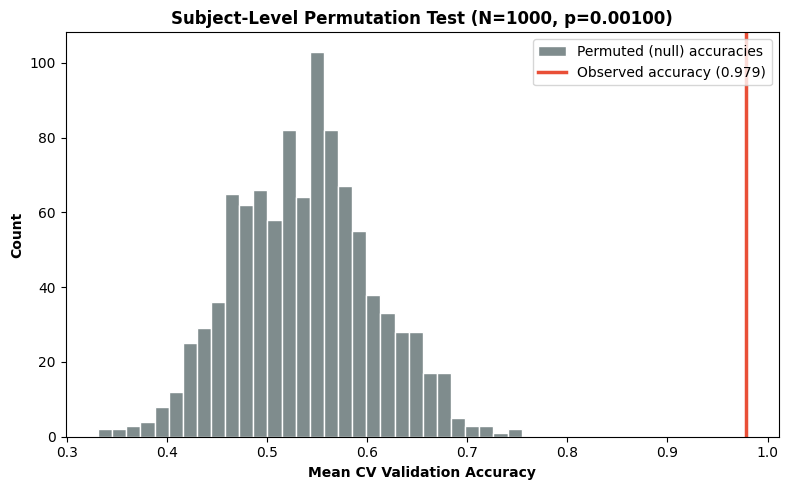

In [2]:
# ============================================================
# SUBJECT-LEVEL PERMUTATION TEST
# ============================================================
# Tests whether the CV accuracy above is significantly better than
# chance under H0: no relationship between connectivity images and
# diagnosis. Labels are shuffled at the SUBJECT level (not per-image),
# so all images belonging to one subject always get the same permuted
# label -- this respects the grouped structure and avoids leakage.
#
# This cell reuses everything already defined in the main pipeline
# cell above: X_t, y, groups, device, CNNModel, augment_batch,
# mixup_data/mixup_criterion, cutmix_data/cutmix_criterion, and all
# hyperparameters (batch_size, num_epochs, learning_rate, weight_decay,
# img_rows, img_cols, n_folds, early_stop_patience, min_epochs,
# dropout_p, spatial_dropout_p). Run the main pipeline cell first.
#
# ------------------------------------------------------------
# COMPUTE COST WARNING
# ------------------------------------------------------------
# Each permutation re-runs the FULL 5-fold CNN training pipeline.
# If one real run of the pipeline above took ~T minutes, N permutations
# will take roughly N x T (early stopping usually makes permuted runs
# faster than the real run, since a shuffled-label model has nothing
# to learn and will trigger early stopping quickly -- but budget for
# the worst case). 1000 permutations is the textbook recommendation,
# but on a CNN + real EEG-derived images this is often impractical.
# Recommended practical path:
#   - Start with N_PERMUTATIONS = 100-200 as a first estimate.
#   - If time allows, extend to 500-1000 by re-running this cell
#     (it checkpoints to disk and resumes automatically).
#   - You can lower PERM_NUM_EPOCHS below num_epochs to cap the worst
#     case per permutation; early stopping will still cut it short
#     when there's no signal.

import time
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedGroupKFold

# -------------------------------------------------
# Config
# -------------------------------------------------
N_PERMUTATIONS   = 1000          # recommended: >= 500-1000
PERM_NUM_EPOCHS  = num_epochs    # lower this (e.g. 15) to bound worst-case runtime
CHECKPOINT_PATH  = "permutation_test_checkpoint.pkl"
MASTER_SEED      = 12345         # for reproducibility of the permutation order

# -------------------------------------------------
# Reusable CV pipeline (identical architecture/training/augmentation
# to the main experiment), parameterized by an arbitrary label vector.
# Returns the mean of each fold's BEST-epoch validation accuracy,
# exactly matching how "Mean Validation Accuracy" was computed above.
# -------------------------------------------------
def run_cv_pipeline(y_labels, groups_arr, X_tensor,
                     num_epochs_local=PERM_NUM_EPOCHS, verbose=False):
    y_t_local = torch.tensor(y_labels).float().unsqueeze(1)

    sgkf_local = StratifiedGroupKFold(n_splits=n_folds)
    fold_accs = []

    for fold, (train_idx, val_idx) in enumerate(
            sgkf_local.split(X_tensor.numpy(), y_labels, groups=groups_arr), 1):

        X_tr, y_tr = X_tensor[train_idx], y_t_local[train_idx]
        X_va, y_va = X_tensor[val_idx],   y_t_local[val_idx]

        # drop_last=True avoids a dangling batch of size 1, which crashes
        # BatchNorm1d in training mode ("Expected more than 1 value per
        # channel"). This can happen on ANY split whose sample count leaves
        # a remainder of exactly 1 after dividing by batch_size -- more
        # likely here since permuted folds can land on different sizes
        # than the original split.
        train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                                   batch_size=batch_size, shuffle=True,
                                   drop_last=(len(X_tr) > batch_size))
        val_loader = DataLoader(TensorDataset(X_va, y_va),
                                 batch_size=batch_size, shuffle=False)

        model = CNNModel(img_rows=img_rows, img_cols=img_cols,
                          dropout_p=dropout_p,
                          spatial_dropout_p=spatial_dropout_p).to(device)

        criterion = nn.BCELoss()
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate,
                                 weight_decay=weight_decay)
        scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_local, eta_min=1e-6)

        best_val_loss = float('inf')
        best_val_acc = 0.0
        patience_counter = 0

        for epoch in range(num_epochs_local):
            # -------- Train --------
            model.train()
            for data_batch, target in train_loader:
                data_batch = data_batch.to(device)
                target = target.to(device)
                data_batch = augment_batch(data_batch)

                r = np.random.rand()
                if r < 0.35:
                    data_batch, targets_a, targets_b, lam = mixup_data(data_batch, target, alpha=0.2)
                    output = model(data_batch)
                    loss = mixup_criterion(criterion, output, targets_a, targets_b, lam)
                elif r < 0.70:
                    data_batch, targets_a, targets_b, lam = cutmix_data(data_batch, target, alpha=1.0)
                    output = model(data_batch)
                    loss = cutmix_criterion(criterion, output, targets_a, targets_b, lam)
                else:
                    output = model(data_batch)
                    loss = criterion(output, target)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            # -------- Validate --------
            model.eval()
            val_loss = 0.0
            correct = 0
            with torch.no_grad():
                for data_batch, target in val_loader:
                    data_batch = data_batch.to(device)
                    target = target.to(device)
                    output = model(data_batch)
                    val_loss += criterion(output, target).item() * data_batch.size(0)
                    pred = (output > 0.5).float()
                    correct += pred.eq(target).sum().item()

            val_loss /= len(val_loader.dataset)
            val_acc = correct / len(val_loader.dataset)
            scheduler.step()

            if verbose:
                print(f"    epoch {epoch+1}/{num_epochs_local} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                patience_counter = 0
            else:
                if (epoch + 1) >= min_epochs:
                    patience_counter += 1
                    if patience_counter >= early_stop_patience:
                        break

        fold_accs.append(best_val_acc)

    return float(np.mean(fold_accs))

# -------------------------------------------------
# Subject-level label permutation
# -------------------------------------------------
def get_subject_label_map(groups_arr, y_arr):
    """Each subject must have exactly one label (control OR dyslexia)."""
    subj_label = {}
    for g in np.unique(groups_arr):
        labels_g = y_arr[groups_arr == g]
        if len(np.unique(labels_g)) != 1:
            raise ValueError(f"Subject {g} has mixed labels — cannot do subject-level permutation.")
        subj_label[g] = labels_g[0]
    return subj_label

subj_label_map     = get_subject_label_map(groups, y)
unique_subjects    = np.array(sorted(subj_label_map.keys()))
true_subject_labels = np.array([subj_label_map[g] for g in unique_subjects])

def permute_subject_labels(unique_subjects, true_subject_labels, groups_arr, rng):
    """Shuffle the subject->label assignment, then broadcast back to sample level."""
    permuted = rng.permutation(true_subject_labels)
    subj_to_perm = dict(zip(unique_subjects, permuted))
    y_perm = np.array([subj_to_perm[g] for g in groups_arr], dtype=np.float32)
    return y_perm

# -------------------------------------------------
# 1) Observed accuracy (true labels), computed with the SAME function
#    used for permutations, so the comparison is apples-to-apples.
# -------------------------------------------------
print("Computing OBSERVED accuracy (true labels) with the permutation-test pipeline...")
observed_acc = run_cv_pipeline(y.astype(np.float32), groups, X_t,
                                num_epochs_local=PERM_NUM_EPOCHS)
print(f"Observed mean CV accuracy: {observed_acc:.4f}\n")

# -------------------------------------------------
# 2) Resume from checkpoint if one exists (so interruptions don't
#    cost you re-training)
# -------------------------------------------------
try:
    with open(CHECKPOINT_PATH, "rb") as f:
        ckpt = pickle.load(f)
    permuted_accs = ckpt["permuted_accs"]
    start_perm = len(permuted_accs)
    print(f"Resuming from checkpoint: {start_perm} permutations already completed.")
except FileNotFoundError:
    permuted_accs = []
    start_perm = 0

rng_master = np.random.default_rng(MASTER_SEED)
# advance the master RNG to the correct point if resuming, so the
# permutation sequence stays reproducible
for _ in range(start_perm):
    rng_master.integers(0, 1_000_000_000)

# -------------------------------------------------
# 3) Permutation loop
# -------------------------------------------------
for p in range(start_perm, N_PERMUTATIONS):
    t0 = time.time()
    rng = np.random.default_rng(rng_master.integers(0, 1_000_000_000))
    y_perm = permute_subject_labels(unique_subjects, true_subject_labels, groups, rng)

    perm_acc = run_cv_pipeline(y_perm, groups, X_t, num_epochs_local=PERM_NUM_EPOCHS)
    permuted_accs.append(perm_acc)

    elapsed = time.time() - t0
    print(f"Permutation {p+1:4d}/{N_PERMUTATIONS} | acc={perm_acc:.4f} | {elapsed:6.1f}s")

    with open(CHECKPOINT_PATH, "wb") as f:
        pickle.dump({"permuted_accs": permuted_accs,
                     "observed_acc": observed_acc}, f)

permuted_accs = np.array(permuted_accs)

# -------------------------------------------------
# 4) p-value and summary
# -------------------------------------------------
# Standard permutation-test p-value with the +1 correction (Phipson &
# Smyth, 2010) -- avoids ever reporting p = 0 from a finite sample.
p_value = (np.sum(permuted_accs >= observed_acc) + 1) / (len(permuted_accs) + 1)

print("\n" + "="*60)
print("SUBJECT-LEVEL PERMUTATION TEST RESULTS")
print("="*60)
print(f"Observed accuracy:          {observed_acc:.4f}")
print(f"Permuted mean accuracy:     {permuted_accs.mean():.4f} (+/- {permuted_accs.std():.4f})")
print(f"Permuted accuracy range:    [{permuted_accs.min():.4f}, {permuted_accs.max():.4f}]")
print(f"Number of permutations:     {len(permuted_accs)}")
print(f"p-value:                    {p_value:.5f}")
print("="*60)

# -------------------------------------------------
# 5) Plot null distribution
# -------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(permuted_accs, bins=30, color="#7f8c8d", edgecolor="white", label="Permuted (null) accuracies")
plt.axvline(observed_acc, color="#E94F37", linewidth=2.5,
            label=f"Observed accuracy ({observed_acc:.3f})")
plt.xlabel("Mean CV Validation Accuracy", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.title(f"Subject-Level Permutation Test (N={len(permuted_accs)}, p={p_value:.5f})",
          fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("permutation_test_null_distribution.png", dpi=300)
plt.show()
